# Grad-CAM implementacija i analiza primenom ResNet-18 modela

U ovom notebook-u biće primenjena Grad-CAM (Gradient-weighted Class Activation Mapping) metoda na pretrenirani ResNet-18 model za klasifikaciju slika.

Cilj je povezivanje matematičke formulacije Grad-CAM metode sa njenom praktičnom implementacijom u PyTorch-u. Umesto korišćenja isključivo postojeće biblioteke za interpretabilnost, Grad-CAM će prvo biti implementiran ručno, izdvajanjem aktivacija i gradijenata odabranog konvolucionog sloja.

Za ciljnu klasu $c$, Grad-CAM koristi gradijente skora klase $y^c$ u odnosu na mape karakteristika $A^k$. Na osnovu ovih gradijenata određuje se značaj svake mape karakteristika za posmatranu klasu, nakon čega se one kombinuju u klasno-specifičnu lokalizacionu mapu.

Implementacija će biti izvedena kroz sledeće korake:

1. Učitavanje potrebnih biblioteka i priprema okruženja.
2. Učitavanje pretreniranog ResNet-18 modela i ulazne slike.
3. Izračunavanje predikcije modela i izbor ciljne klase.
4. Izdvajanje aktivacija $A^k$ iz odabranog konvolucionog sloja.
5. Izračunavanje gradijenata skora ciljne klase $y^c$.
6. Izračunavanje Grad-CAM težina $\alpha_k^c$.
7. Formiranje Grad-CAM lokalizacione mape.
8. Interpolacija i prikaz lokalizacione mape preko originalne slike.
9. Poređenje ručne implementacije sa `LayerGradCam` implementacijom iz Captum biblioteke.

## 1. Priprema okruženja

Najpre se učitavaju biblioteke potrebne za rad sa PyTorch modelom, obradu ulazne slike, numeričke operacije i vizualizaciju rezultata.

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image
from torchvision import models, transforms

### 1.1. Izbor uređaja za izvršavanje

PyTorch omogućava izvršavanje tenzorskih operacija na različitim uređajima. Pošto se notebook izvršava na Apple Silicon računaru, koristi se MPS (Metal Performance Shaders) ukoliko je dostupan. U suprotnom, izvršavanje se obavlja na CPU-u.

Izabrani uređaj će se koristiti i za model i za ulazne tenzore.

In [ ]:
# Select computation device
if torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print("Device:", device)

## 2. Učitavanje pretreniranog ResNet-18 modela i ulazne slike

U ovom koraku učitava se pretrenirani ResNet-18 model koji će biti korišćen za klasifikaciju slike i kasniju primenu Grad-CAM metode.

ResNet (Residual Network) arhitektura zasniva se na rezidualnim blokovima koji uvode direktne veze (engl. *skip connections*) između ulaza i izlaza bloka. Osnovna ideja rezidualnog bloka može se predstaviti izrazom:

$$
y = F(x) + x
$$

gde je $x$ ulaz u rezidualni blok, $F(x)$ transformacija realizovana slojevima unutar bloka, dok je $y$ izlaz bloka.

Za Grad-CAM su posebno značajni konvolucioni slojevi mreže, jer njihove mape karakteristika zadržavaju prostornu informaciju o sadržaju ulazne slike.

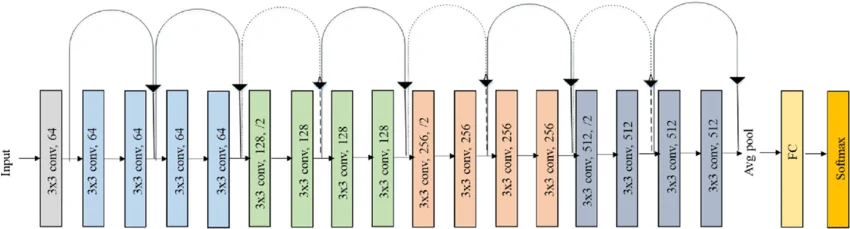

### 2.1. Učitavanje ResNet-18 modela

Koristi se ResNet-18 model sa pretreniranim težinama. Pretrenirane težine omogućavaju korišćenje modela koji je već naučio vizuelne karakteristike potrebne za klasifikaciju slika, bez ponovnog treniranja modela od početka.

Model se prebacuje na prethodno izabrani uređaj i postavlja u režim evaluacije.

In [ ]:
# Load pretrained ResNet-18 weights
weights = models.ResNet18_Weights.DEFAULT

# Create the pretrained model
model = models.resnet18(weights=weights)

# Move the model to the selected device and set evaluation mode
model = model.to(device)
model.eval()

print(model)

### 2.2. Učitavanje ulaznih slika

Za analizu će biti korišćene tri slike različite složenosti. Prva slika sadrži jasno izdvojen objekat (kakadu), druga predstavlja složeniju scenu sa većim brojem ljudi, dok treća predstavlja auto kao još jedan primer jasno prepoznatljivog objekta.

Korišćenje različitih ulaznih scena omogućiće kasnije poređenje ponašanja Grad-CAM metode u jednostavnim i složenijim slučajevima.

In [ ]:
# Create directory for classification images
!mkdir -p img/classification

# Download test images
!curl -sL "https://commons.wikimedia.org/wiki/Special:Redirect/file/SulphurCrestedCockatoo.jpg" -o img/classification/cockatoo.jpg
!curl -sL "https://commons.wikimedia.org/wiki/Special:Redirect/file/Street_Crowd.jpg" -o img/classification/crowd.jpg
!curl -sL "https://commons.wikimedia.org/wiki/Special:Redirect/file/Modern_small_car.jpg" -o img/classification/car.jpg

Slike se učitavaju pomoću PIL biblioteke i konvertuju u RGB format sa tri kanala, koji odgovara ulazu ResNet-18 modela.

Pre pretprocesiranja, slike se prikazuju zajedno sa njihovim originalnim dimenzijama.

In [ ]:
# Define image paths
image_paths = {
    "Cockatoo": "img/classification/cockatoo.jpg",
    "Crowd": "img/classification/crowd.jpg",
    "Car": "img/classification/car.jpg"
}

# Load images and convert them to RGB
images = {
    name: Image.open(path).convert("RGB")
    for name, path in image_paths.items()
}

# Display original images
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, (name, image) in zip(axes, images.items()):
    ax.imshow(image)
    ax.set_title(f"{name} - {image.size[0]} x {image.size[1]}")
    ax.axis("off")

plt.tight_layout()
plt.show()

### 2.3. Pretprocesiranje ulaznih slika

Pre prosleđivanja modelu, ulazne slike moraju biti transformisane u format koji odgovara ResNet-18 modelu i korišćenim pretreniranim težinama.

Potrebne transformacije preuzimaju se direktno iz objekta `weights`. One obuhvataju promenu veličine slike, izdvajanje centralnog dela slike, konverziju u tenzor i normalizaciju RGB kanala.

Nakon pretprocesiranja svaka slika je predstavljena tenzorom oblika $[3, 224, 224]$. Dodavanjem batch dimenzije dobija se oblik $[1, 3, 224, 224]$, koji može biti prosleđen modelu.

In [ ]:
# Get the preprocessing transformations associated with the pretrained weights
preprocess = weights.transforms()

# Preprocess all input images
input_tensors = {
    name: preprocess(image).unsqueeze(0).to(device)
    for name, image in images.items()
}

# Print tensor shapes
for name, tensor in input_tensors.items():
    print(f"{name}: {tensor.shape}")

print(preprocess)

Pretprocesiranje korišćenih težina prvo menja veličinu slike tako da kraća stranica ima 256 piksela, a zatim izdvaja centralni deo veličine $224 \times 224$ piksela. RGB kanali se potom normalizuju korišćenjem zadatih srednjih vrednosti i standardnih devijacija.

## 3. Izračunavanje predikcije modela i izbor ciljne klase

Pretprocesirane slike se prosleđuju ResNet-18 modelu kako bi se dobili skorovi za sve izlazne klase.

Za svaku ulaznu sliku model daje izlazni vektor sa 1000 vrednosti:

$$
\mathbf{y} = [y^1, y^2, \ldots, y^{1000}]
$$

gde $y^c$ predstavlja skor modela za klasu $c$. Klasa sa najvećim skorom predstavlja predikciju modela.

Za Grad-CAM će upravo skor izabrane klase $y^c$ predstavljati veličinu čiji uticaj želimo da objasnimo.

In [ ]:
# Get ImageNet class names
categories = weights.meta["categories"]

# Make predictions for all input images
for name, input_tensor in input_tensors.items():
    with torch.no_grad():
        output = model(input_tensor)

    probabilities = torch.softmax(output, dim=1)

    predicted_index = probabilities.argmax(dim=1).item()
    predicted_probability = probabilities[0, predicted_index].item()
    predicted_class = categories[predicted_index]

    print(
        f"{name}: {predicted_class} "
        f"({predicted_probability * 100:.2f}%)"
    )

## 4. Izdvajanje aktivacija $A^k$ iz odabranog konvolucionog sloja

Grad-CAM koristi mape karakteristika odabranog konvolucionog sloja. Za mapu karakteristika $k$ koristi se oznaka:

$$
A^k
$$

Za ResNet-18 bira se poslednji konvolucioni sloj:

`model.layer4[1].conv2`

Ovaj sloj proizvodi 512 mapa karakteristika. Njihove aktivacije biće sačuvane tokom forward pass-a kako bi se kasnije povezale sa gradijentima skora izabrane klase.

### 4.1. Izbor konvolucionog sloja

Za Grad-CAM se obično bira konvolucioni sloj pri kraju mreže, jer njegove mape karakteristika sadrže složenije semantičke informacije, a još uvek zadržavaju prostornu strukturu slike.

U ovom slučaju koristi se poslednji konvolucioni sloj poslednjeg rezidualnog bloka.

In [ ]:
# Select the target convolutional layer
target_layer = model.layer4[1].conv2

print(target_layer)

### 4.2. Čuvanje aktivacija

Da bi se dobile aktivacije ciljnog sloja bez menjanja same arhitekture ResNet-18 modela, koristi se PyTorch `forward hook`.

Hook predstavlja funkciju koja se automatski poziva kada se izvrši odabrani sloj. Na ovaj način moguće je sačuvati izlaz ciljnog konvolucionog sloja tokom normalnog forward pass-a kroz mrežu.

In [ ]:
# Dictionary used to store target layer activations
activations = {}

def save_activations(module, inputs, output):
    activations["value"] = output
    output.retain_grad()

# Register forward hook
hook_handle = target_layer.register_forward_hook(save_activations)

## 5. Izračunavanje gradijenata skora ciljne klase $y^c$

Nakon izdvajanja aktivacija ciljnog konvolucionog sloja potrebno je odrediti koliko svaka od njih utiče na skor izabrane klase.

Za ciljnu klasu $c$, računaju se gradijenti:

$$
\frac{\partial y^c}{\partial A_{ij}^k}
$$

gde je $y^c$ skor ciljne klase, a $A_{ij}^k$ vrednost $k$-te mape karakteristika na prostornoj poziciji $(i,j)$.

Za razliku od prethodnog koraka klasifikacije, ovde se ne koristi `torch.no_grad()`, jer je računanje gradijenata neophodno za Grad-CAM.

In [ ]:
# Select one input image
input_tensor = input_tensors["Cockatoo"]

# Clear previously calculated gradients
model.zero_grad()

# Forward pass
output = model(input_tensor)

# Select the predicted class
target_class = output.argmax(dim=1).item()

# Select the score of the target class
target_score = output[0, target_class]

print("Target class:", categories[target_class])
print("Target class index:", target_class)
print("Target score:", target_score.item())

In [ ]:
# Backpropagate the target class score
target_score.backward()

# Get activations and their gradients
feature_maps = activations["value"]
gradients = feature_maps.grad

print("Feature maps shape:", feature_maps.shape)
print("Gradients shape:", gradients.shape)

## 6. Izračunavanje Grad-CAM težina $\alpha_k^c$

Gradijenti pokazuju kako promena pojedinačnih vrednosti mape karakteristika utiče na skor ciljne klase $y^c$.

Grad-CAM određuje značaj svake mape karakteristika $A^k$ tako što računa prosečnu vrednost njenih gradijenata po prostornim dimenzijama:

$$
\alpha_k^c =
\frac{1}{Z}
\sum_i \sum_j
\frac{\partial y^c}{\partial A_{ij}^k}
$$

gde $Z$ predstavlja broj prostornih elemenata mape karakteristika. U našem slučaju svaka mapa ima dimenzije $7 \times 7$, pa je $Z=49$.

Na ovaj način se za svaku od 512 mapa karakteristika dobija po jedna težina $\alpha_k^c$.

In [ ]:
# Calculate Grad-CAM weights by global average pooling of gradients
weights_gradcam = gradients.mean(dim=(2, 3), keepdim=True)

print("Gradients shape:", gradients.shape)
print("Grad-CAM weights shape:", weights_gradcam.shape)

## 7. Formiranje Grad-CAM lokalizacione mape

Nakon izračunavanja težina $\alpha_k^c$, svaka mapa karakteristika $A^k$ množi se svojom odgovarajućom težinom. Dobijene ponderisane mape se zatim sabiraju:

$$
\sum_k \alpha_k^c A^k
$$

Na rezultat se primenjuje ReLU funkcija, čime se dobija Grad-CAM lokalizaciona mapa za ciljnu klasu:

$$
L_{\mathrm{Grad-CAM}}^c =
\operatorname{ReLU}
\left(
\sum_k \alpha_k^c A^k
\right)
$$

ReLU zadržava pozitivne vrednosti, odnosno regione koji pozitivno utiču na skor izabrane klase.

In [ ]:
# Weight each feature map by its Grad-CAM importance
weighted_feature_maps = weights_gradcam * feature_maps

# Sum over all feature maps
gradcam = weighted_feature_maps.sum(dim=1, keepdim=True)

# Keep only positive contributions
gradcam = torch.relu(gradcam)

print("Weighted feature maps shape:", weighted_feature_maps.shape)
print("Grad-CAM shape:", gradcam.shape)

## 8. Interpolacija i prikaz lokalizacione mape preko originalne slike

Dobijena Grad-CAM mapa ima prostorne dimenzije $7 \times 7$, koje odgovaraju izlazu odabranog konvolucionog sloja. Da bi se mapa mogla prikazati preko ulazne slike, potrebno je povećati je na dimenzije $224 \times 224$.

Za povećanje mape koristi se bilinearna interpolacija. Nakon interpolacije, vrednosti Grad-CAM mape se normalizuju na opseg $[0,1]$ radi jednostavnije vizualizacije.

Veće vrednosti Grad-CAM mape označavaju regione koji imaju veći pozitivan uticaj na skor izabrane klase.

In [ ]:
import torch.nn.functional as F

# Upsample Grad-CAM to the input image size
gradcam_upsampled = F.interpolate(
    gradcam,
    size=(224, 224),
    mode="bilinear",
    align_corners=False
)

# Normalize Grad-CAM to [0, 1]
gradcam_upsampled = gradcam_upsampled - gradcam_upsampled.min()
gradcam_upsampled = gradcam_upsampled / gradcam_upsampled.max()

print("Original Grad-CAM shape:", gradcam.shape)
print("Upsampled Grad-CAM shape:", gradcam_upsampled.shape)

### 8.1. Vizualizacija Grad-CAM mape

Za prikaz rezultata koristi se ulazna slika nakon promene veličine i centralnog isecanja, ali bez normalizacije RGB vrednosti.

Grad-CAM mapa se prikazuje zasebno, a zatim i preko ulazne slike. Regioni sa većim vrednostima Grad-CAM mape predstavljaju regione sa većim pozitivnim uticajem na skor izabrane klase.

In [ ]:
# Prepare the input image for visualization
visualize_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224)
])

display_image = visualize_transform(images["Cockatoo"])

# Convert Grad-CAM to NumPy
heatmap = gradcam_upsampled.squeeze().detach().cpu().numpy()

# Display the input image, Grad-CAM and overlay
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(display_image)
axes[0].set_title("Input image")
axes[0].axis("off")

axes[1].imshow(heatmap, cmap="jet")
axes[1].set_title("Grad-CAM")
axes[1].axis("off")

axes[2].imshow(display_image)
axes[2].imshow(heatmap, cmap="jet", alpha=0.5)
axes[2].set_title(f"Grad-CAM: {categories[target_class]}")
axes[2].axis("off")

plt.tight_layout()
plt.show()

### 8.2. Primena Grad-CAM metode na ostale ulazne slike

Isti postupak se primenjuje na preostale dve slike kako bi se uporedilo ponašanje Grad-CAM metode na složenijoj sceni sa većim brojem objekata i na slici automobila.

In [ ]:
# Apply Grad-CAM to the remaining images
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

for row, name in enumerate(["Crowd", "Car"]):

    # Clear previously calculated gradients
    model.zero_grad()

    # Forward pass
    output = model(input_tensors[name])

    # Select predicted class and its score
    target_class = output.argmax(dim=1).item()
    target_score = output[0, target_class]

    # Backward pass
    target_score.backward()

    # Get feature maps and gradients
    feature_maps = activations["value"]
    gradients = feature_maps.grad

    # Calculate Grad-CAM weights
    weights_gradcam = gradients.mean(dim=(2, 3), keepdim=True)

    # Create Grad-CAM localization map
    gradcam_result = (weights_gradcam * feature_maps).sum(dim=1, keepdim=True)
    gradcam_result = torch.relu(gradcam_result)

    # Upsample Grad-CAM to 224x224
    gradcam_result = F.interpolate(
        gradcam_result,
        size=(224, 224),
        mode="bilinear",
        align_corners=False
    )

    # Normalize Grad-CAM to [0, 1]
    gradcam_result = gradcam_result - gradcam_result.min()
    gradcam_result = gradcam_result / gradcam_result.max()

    # Convert Grad-CAM to NumPy
    heatmap = gradcam_result.squeeze().detach().cpu().numpy()

    # Prepare input image for visualization
    display_image = visualize_transform(images[name])

    # Display input image
    axes[row, 0].imshow(display_image)
    axes[row, 0].set_title(f"{name} - Input")
    axes[row, 0].axis("off")

    # Display Grad-CAM heatmap
    axes[row, 1].imshow(heatmap, cmap="jet")
    axes[row, 1].set_title("Grad-CAM")
    axes[row, 1].axis("off")

    # Display overlay
    axes[row, 2].imshow(display_image)
    axes[row, 2].imshow(heatmap, cmap="jet", alpha=0.5)
    axes[row, 2].set_title(f"Grad-CAM: {categories[target_class]}")
    axes[row, 2].axis("off")

    print(f"{name}: {categories[target_class]}")

plt.tight_layout()
plt.show()

## 9. Poređenje ručne implementacije sa `LayerGradCam` implementacijom iz Captum biblioteke

Za proveru ručne implementacije koristi se `LayerGradCam` metoda iz Captum biblioteke. Kao ciljni sloj koristi se isti konvolucioni sloj `model.layer4[1].conv2`, a kao cilj ista klasa koju je ResNet-18 predvideo za ulaznu sliku.

Captum interno računa gradijente ciljnog skora u odnosu na aktivacije izabranog sloja i na osnovu njih formira Grad-CAM mapu.

Dobijena mapa se interpolira na dimenzije $224 \times 224$ i normalizuje na opseg $[0,1]$, kako bi se rezultat mogao direktno uporediti sa ručno izračunatom Grad-CAM mapom.

In [ ]:
from captum.attr import LayerGradCam, LayerAttribution

# Create Captum LayerGradCam object for the same target layer
layer_gradcam = LayerGradCam(model, target_layer)

# Use the Cockatoo image for comparison
input_tensor = input_tensors["Cockatoo"]

# Get model prediction
output = model(input_tensor)
target_class = output.argmax(dim=1).item()

# Calculate Grad-CAM using Captum
captum_gradcam = layer_gradcam.attribute(
    input_tensor,
    target=target_class
)

# Upsample Captum Grad-CAM to 224x224
captum_gradcam = LayerAttribution.interpolate(
    captum_gradcam,
    (224, 224)
)

# Apply ReLU and normalize to [0, 1]
captum_gradcam = torch.relu(captum_gradcam)
captum_gradcam = captum_gradcam - captum_gradcam.min()
captum_gradcam = captum_gradcam / captum_gradcam.max()

# Convert Captum Grad-CAM to NumPy
captum_heatmap = captum_gradcam.squeeze().detach().cpu().numpy()

# Manual Grad-CAM result from Point 8
manual_heatmap = gradcam_upsampled.squeeze().detach().cpu().numpy()

# Prepare image for visualization
display_image = visualize_transform(images["Cockatoo"])

# Compare manual implementation and Captum
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(display_image)
axes[0].set_title("Input image")
axes[0].axis("off")

axes[1].imshow(display_image)
axes[1].imshow(manual_heatmap, cmap="jet", alpha=0.5)
axes[1].set_title("Manual Grad-CAM")
axes[1].axis("off")

axes[2].imshow(display_image)
axes[2].imshow(captum_heatmap, cmap="jet", alpha=0.5)
axes[2].set_title("Captum LayerGradCam")
axes[2].axis("off")

plt.tight_layout()
plt.show()

print("Target class:", categories[target_class])

### 9.1. Poređenje rezultata

Ručna implementacija i Captum `LayerGradCam` koriste isti osnovni princip: gradijenti skora ciljne klase koriste se za određivanje značaja mapa karakteristika odabranog konvolucionog sloja.

Sličnost dobijenih lokalizacionih mapa pokazuje vezu između matematičke formulacije Grad-CAM metode i njene implementacije u Captum biblioteci. Ručna implementacija pritom omogućava direktno praćenje aktivacija $A^k$, gradijenata $\frac{\partial y^c}{\partial A_{ij}^k}$, težina $\alpha_k^c$ i konačne Grad-CAM mape.